In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
print(sys.executable)
SRC_SUBDIR = '../..'
SRC_SUBDIR = os.path.abspath(SRC_SUBDIR)
if SRC_SUBDIR not in sys.path:
    print(f'Adding source directory to the sys.path: {SRC_SUBDIR!r}')
    sys.path.insert(1, SRC_SUBDIR)

/opt/homebrew/Caskroom/miniforge/base/envs/nlops/bin/python
Adding source directory to the sys.path: '/Volumes/Data/Projects/NLOperators'


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sir_modelling import simulate_epidemic

In [3]:
Npopulation = 1.0e7
sirmodpars = np.array([0.23, 0.11])
sirdata, tvalues, sirmod = simulate_epidemic(T = 280, dt = 0.1, Tsub=1.0, Npopulation = Npopulation, sir_model = sirmodpars)


{'units': 'days'}


In [4]:
def configure_dataset(sirdata, data_attributes):
    assert sirdata.shape[0] == len(tvalues)
    assert sirdata.shape[1] == len(data_attributes)

    dataset = [None]*sirdata.shape[1]
    for i, attrs in enumerate(data_attributes):
        datadict = attrs
        datadict["data"]=sirdata[:,i]
        dataset[i] = datadict
    return dataset

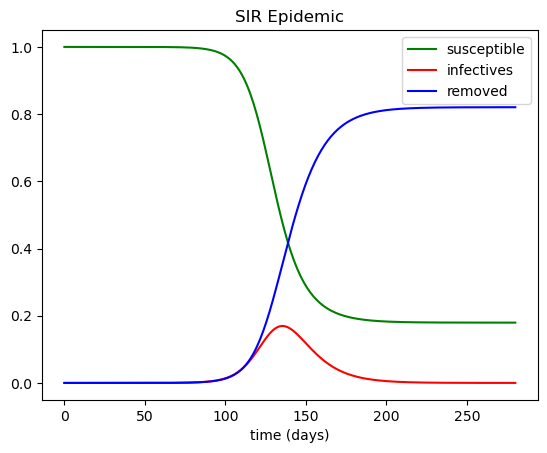

In [5]:
def plot_dataset(dataset, tvalues, path = None):
    
    assert sirdata.shape[0] == len(tvalues)
    nticks =11
    M = 1.0e6

    for attrs in dataset:
        data = attrs["data"]
        assert data.size == len(tvalues), f"{data.size=} != {len(tvalues)}"
        plt.plot(tvalues, attrs["data"], linestyle=attrs["linestyle"], label=attrs["label"], color=attrs["color"])
        #yticks = np.linspace(0, 1, num=nticks)
        #ylabels = [f"{value / M:.1f} M" for value in yticks] 
        #plt.yticks(yticks, labels=ylabels)
        plt.xlabel("time (days)")
    plt.title("SIR Epidemic")
    plt.legend()
    if path is not None:
        plt.savefig(path)

sir_attributes = [
    {"linestyle":"-", "label": "susceptible", "color":"g"}, 
    {"linestyle":"-", "label": "infectives" , "color":"r"},
    {"linestyle":"-", "label": "removed"    , "color":"b"}
]
sirdataset = configure_dataset(sirdata, sir_attributes) 
plot_dataset(sirdataset, tvalues, "sir_mod.png")

iteration 10 : 11.925899253523092
iteration 20 : 11.851740727840982
iteration 30 : 6.33027409775487
iteration 40 : 2.0133607719380073
iteration 50 : 0.8096650041205752
iteration 60 : 0.14661631627802527
iteration 70 : 0.022100722476155125
iteration 80 : 0.004244746286094357
iteration 90 : 2.96275321153779e-07
final_model = [9.999999e-01 1.000000e-07 2.300000e-01 1.100000e-01]


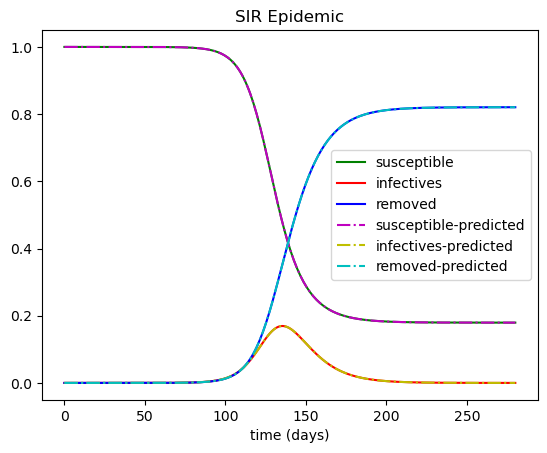

In [6]:
from sir_inversion import SIRInversion, SIRFixedInversion
sirinv = SIRInversion.from_sirmod(sirmod=sirmod, data=sirdata)
results = sirinv(x0 = np.array([1.0, 0.0, 0.18, 0.15]))
print(f"final_model = {results["final_model"]}")
data_comparison = np.concatenate([sirdata, results["sirdata"]], axis=1)
data_attributes = [
    {"linestyle":"-", "label": "susceptible", "color":"g"}, 
    {"linestyle":"-", "label": "infectives" , "color":"r"},
    {"linestyle":"-", "label": "removed"    , "color":"b"},
    {"linestyle":"-.", "label": "susceptible-predicted", "color":"m"}, 
    {"linestyle":"-.", "label": "infectives-predicted" , "color":"y"},
    {"linestyle":"-.", "label": "removed-predicted"    , "color":"c"}
]
comparison = configure_dataset(data_comparison, data_attributes) 
plot_dataset(comparison, tvalues)


Text(0.5, 1.0, 'Objective function: convergence')

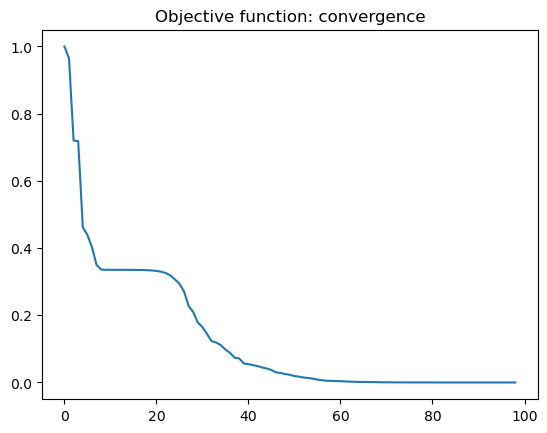

In [7]:
plt.plot(results["iterations"])
plt.title("Objective function: convergence")

In [8]:
sirfixedinv = SIRFixedInversion.from_sirmod(sirmod=sirmod, data=sirdata, model0= np.array([0.2,0.1]))
fixedresults = sirfixedinv(x0 = np.array([1.0, 0.0]))
print(f"final_model = {fixedresults["final_model"]}")


TypeError: 'int' object is not iterable

Text(0.5, 1.0, 'Objective function: convergence')

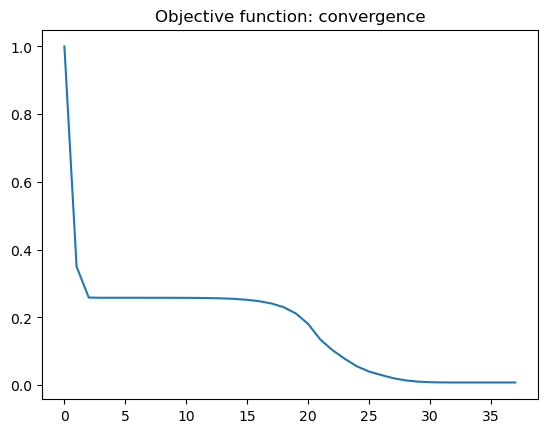

In [ ]:
plt.plot(fixedresults["iterations"])
plt.title("Objective function: convergence")

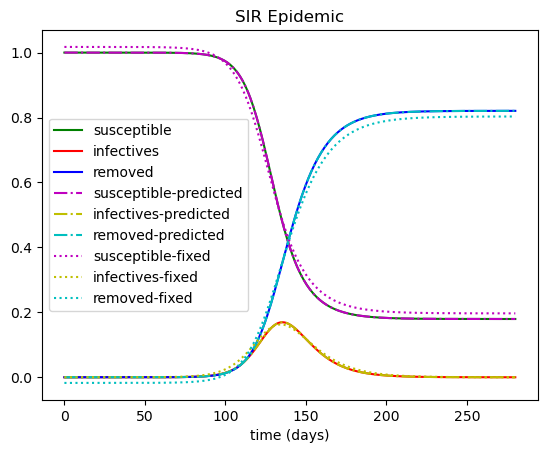

In [ ]:
data_comparison = np.concatenate([sirdata, results["sirdata"], fixedresults["sirdata"]], axis=1)
data_attributes = [
    {"linestyle":"-", "label": "susceptible", "color":"g"}, 
    {"linestyle":"-", "label": "infectives" , "color":"r"},
    {"linestyle":"-", "label": "removed"    , "color":"b"},
    {"linestyle":"-.", "label": "susceptible-predicted", "color":"m"}, 
    {"linestyle":"-.", "label": "infectives-predicted" , "color":"y"},
    {"linestyle":"-.", "label": "removed-predicted"    , "color":"c"},
    {"linestyle":":", "label": "susceptible-fixed", "color":"m"}, 
    {"linestyle":":", "label": "infectives-fixed" , "color":"y"},
    {"linestyle":":", "label": "removed-fixed"    , "color":"c"}
]
comparison = configure_dataset(data_comparison, data_attributes) 
plot_dataset(comparison, tvalues)

In [ ]:
def configure_mean_std(predicted, nsamples):
    std = np.sqrt(predicted*(1-predicted)/nsamples)
    return (predicted, std)

def plot_samples(sampled_infectives, true_infectives, predicted_mean_std):   
    mean, std = predicted_mean_std
    plt.plot(tvalues, sampled_infectives, label="sampled infectives", color="blue")
    plt.plot(tvalues, true_infectives, label="true infectives", color="red")
    plt.plot(tvalues, mean, label="predicted infectives", color="black")

    for mult in range(1,4):
        plt.fill_between(tvalues, mean - mult*std, mean + mult*std, color="grey", alpha=0.25/mult)
    plt.title("SIR Samples")
    plt.legend()


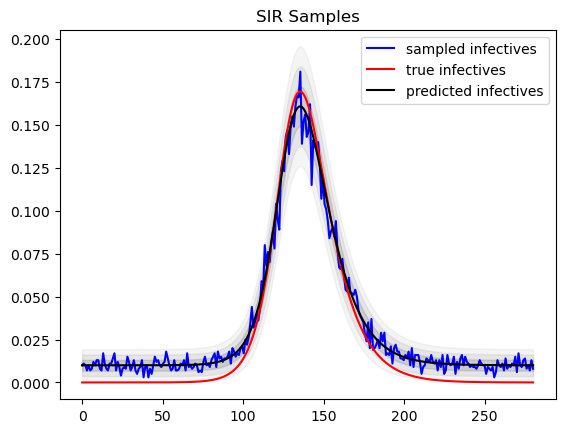

In [ ]:
from sir_modelling import sample
ptp=0.9
pfp=0.01
nsamples =1000
true_infectives = sirdata[:, 1]
sampled_infectives = sample(true_infectives, ptp, pfp, nsamples)/nsamples
predicted = ptp*true_infectives + pfp*(1-true_infectives)
predicted_mean_std = configure_mean_std(predicted, nsamples)
plot_samples(sampled_infectives, true_infectives, predicted_mean_std)

In [ ]:
from src.operators.base import check_dot_product, check_linearization
test_input = np.array([0.9, 0.1, 0.21, 0.11, 0.9, 0.1])
sir_sample_mod = sirmod.create_sampler()
check_linearization(sir_sample_mod, test_input)
check_dot_product(sir_sample_mod, test_input)

In [ ]:
def plot_results(sirdata, sampled_infectives, sirpredicted, predicted_infectives, nsamples):
    fig, axs = plt.subplots(2,2) 
    
    mean, std = configure_mean_std(predicted_infectives, nsamples)
   
    axs[0,0].plot(tvalues, sampled_infectives, label="sampled infectives", color="blue")
    axs[0,0].plot(tvalues, mean, label="predicted infectives", color="black")

    for mult in range(1,4):
        axs[0,0].fill_between(tvalues, mean - mult*std, mean + mult*std, color="grey", alpha=0.25/mult)
    axs[0,0].legend()

    axs[0,1].plot(tvalues, sirdata[:,1], label="true infectives", color="red")
    axs[0,1].plot(tvalues, sirpredicted[:,1], label="modelled infectives", color="magenta")
    axs[0,1].legend()
    axs[1,0].plot(tvalues, sirdata[:, 0], linestyle="-", label="susceptible", color="green")
    axs[1,0].plot(tvalues, sirdata[:, 1], linestyle="-", label="infectives", color="red")
    axs[1,0].plot(tvalues, sirdata[:, 2], linestyle="-", label="removed", color="blue")
    axs[1,0].legend()
    axs[1,1].plot(tvalues, sirpredicted[:,0], linestyle="-", label="predicted-susceptible", color="green")
    axs[1,1].plot(tvalues, sirpredicted[:,1], linestyle="-", label="predicted-infectives", color="red")
    axs[1,1].plot(tvalues, sirpredicted[:,2], linestyle="-", label="predicted-removed", color="blue")
    axs[1,1].legend()
    plt.show()

In [ ]:
from sir_inversion import run_infectives_inversion
initial_condition = np.array([1.0,0.0])
initial_model = np.array([0.2,0.1])
sample_params = np.array([0.99,0.01])
results = run_infectives_inversion(
    sampled_infectives, sir_sample_mod, 
    initial_condition, initial_model, sample_params)

standard mode
iteration 10 : 0.0051660994165623145
iteration 20 : 0.004730080409498717
iteration 30 : 0.004656853470754977
iteration 40 : 0.0045993898749227425
iteration 50 : 0.004537717519770987
iteration 60 : 0.004488632237841114
iteration 70 : 0.00443525022559993
iteration 80 : 0.004383547452258565
iteration 90 : 0.004337995760429231
iteration 100 : 0.004308831503079544
iteration 110 : 0.00425691850397824
iteration 120 : 0.004217640615943683
iteration 130 : 0.004182876265901438
iteration 140 : 0.004146597450025346
iteration 150 : 0.004118610952855912
iteration 160 : 0.004090173608540193
iteration 170 : 0.004068965394986138
iteration 180 : 0.004045161674293655
iteration 190 : 0.0040286230107145615
iteration 200 : 0.004012026695822041
iteration 210 : 0.003997269919270342
iteration 220 : 0.003985070033281144
iteration 230 : 0.0039746394291622885
iteration 240 : 0.00396697861008097
iteration 250 : 0.003961279751117413
iteration 260 : 0.003956978106529051
iteration 270 : 0.00395413805218

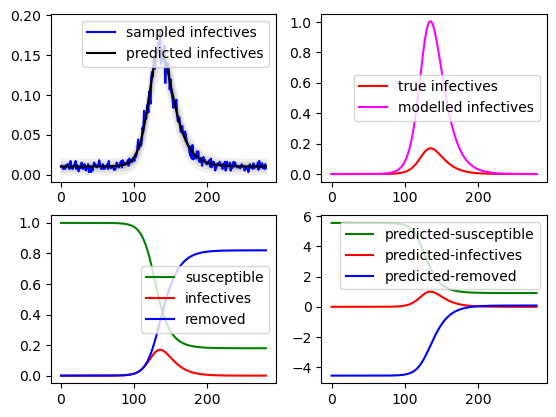

In [ ]:
plot_results(sirdata, sampled_infectives, results["sirdata"], results["predicted_samples"], nsamples)

In [ ]:
results_fixed = run_infectives_inversion(
    sampled_infectives, sir_sample_mod,
    initial_condition, initial_model, sample_params, 
    fixed_model=True
)

using fixed model
iteration 10 : 0.005370311604561461
iteration 20 : 0.005353077667509259
iteration 30 : 0.004294493753232709
iteration 40 : 0.00395942969822736
iteration 50 : 0.003956571805209193


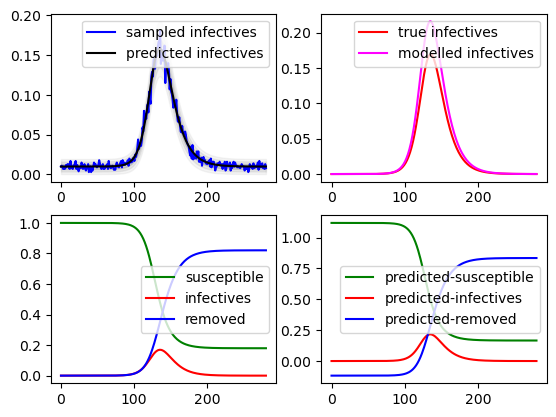

In [ ]:
plot_results(sirdata, sampled_infectives, results_fixed["sirdata"], results_fixed["predicted_samples"], nsamples)

In [ ]:
xreg = np.concatenate([initial_condition, initial_model , sample_params])
results_regul = run_infectives_inversion(
    sampled_infectives, sir_sample_mod, 
    initial_condition, initial_model, sample_params, 
    regularization=(xreg, 10)
)

standard mode
using regularization: (array([1.  , 0.  , 0.2 , 0.1 , 0.99, 0.01]), 10)
iteration 10 : 0.006605617585999677
iteration 20 : 0.0066054513150577854
iteration 30 : 0.006563825914468406
iteration 40 : 0.006554409835370131


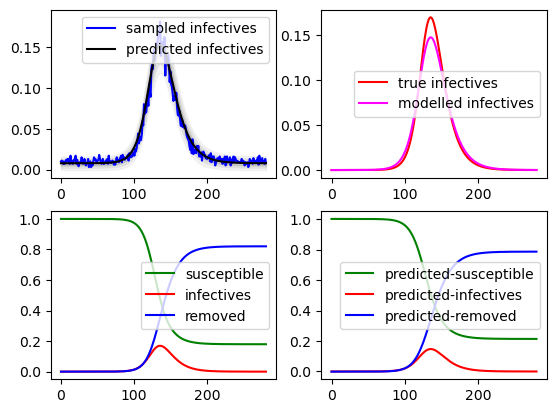

In [ ]:
plot_results(sirdata, sampled_infectives, results_regul["sirdata"], results_regul["predicted_samples"], nsamples)

In [ ]:
binomial_initial_condition = np.array([0.99, 0.01])
xreg = np.concatenate([initial_condition, initial_model , sample_params])
results_binomial_fit = run_infectives_inversion(
    sampled_infectives, sir_sample_mod, 
    binomial_initial_condition, initial_model, sample_params, 
    regularization=(xreg, 10), datafit = "Binomial"
)

standard mode
using regularization: (array([1.  , 0.  , 0.2 , 0.1 , 0.99, 0.01]), 10)


/var/folders/9z/gnh2kkc16s75l6x00nnb38l00000gn/T/ipykernel_7174/2029815732.py:2: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(predicted*(1-predicted)/nsamples)


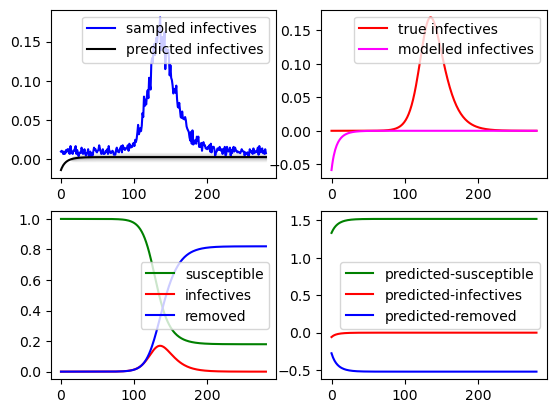

In [ ]:
plot_results(sirdata, sampled_infectives, results_binomial_fit["sirdata"], results_binomial_fit["predicted_samples"], nsamples)